In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
fd = pd.read_excel("loan_data.xlsx")
fd

,Applicant_ID,Income,Loan_Amount,Credit_Score,Employment_Type,Loan_Status
0,701,30000,200000,650,Salaried,Rejected
1,702,50000,300000,720,Self-Employed,Approved
2,703,40000,250000,680,Salaried,Approved
3,704,80000,500000,750,Salaried,Approved
4,705,60000,350000,700,Self-Employed,Approved
5,706,35000,220000,640,Salaried,Rejected
6,707,90000,600000,780,Salaried,Approved
7,708,45000,280000,690,Self-Employed,Approved
8,709,70000,450000,740,Salaried,Approved
9,710,55000,320000,710,Salaried,Approved


In [4]:
fd.head()

,Applicant_ID,Income,Loan_Amount,Credit_Score,Employment_Type,Loan_Status
0,701,30000,200000,650,Salaried,Rejected
1,702,50000,300000,720,Self-Employed,Approved
2,703,40000,250000,680,Salaried,Approved
3,704,80000,500000,750,Salaried,Approved
4,705,60000,350000,700,Self-Employed,Approved


In [5]:
fd.tail()

,Applicant_ID,Income,Loan_Amount,Credit_Score,Employment_Type,Loan_Status
5,706,35000,220000,640,Salaried,Rejected
6,707,90000,600000,780,Salaried,Approved
7,708,45000,280000,690,Self-Employed,Approved
8,709,70000,450000,740,Salaried,Approved
9,710,55000,320000,710,Salaried,Approved


In [6]:
fd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Applicant_ID     10 non-null     int64 
 1   Income           10 non-null     int64 
 2   Loan_Amount      10 non-null     int64 
 3   Credit_Score     10 non-null     int64 
 4   Employment_Type  10 non-null     object
 5   Loan_Status      10 non-null     object
dtypes: int64(4), object(2)
memory usage: 612.0+ bytes


In [7]:
fd1 = {
"Income_Level":["Low","Medium","Medium","High","High","Low","High","Medium","High","Medium"],
"Credit_Category":["Fair","Excellent","Good","Excellent","Good","Poor","Excellent","Good","Excellent","Excellent"]
}

In [8]:
fd1 = pd.DataFrame(fd1)
fd1

,Income_Level,Credit_Category
0,Low,Fair
1,Medium,Excellent
2,Medium,Good
3,High,Excellent
4,High,Good
5,Low,Poor
6,High,Excellent
7,Medium,Good
8,High,Excellent
9,Medium,Excellent


In [9]:
Loan_Data = pd.merge(fd, fd1, left_index=True, right_index=True)
Loan_Data

,Applicant_ID,Income,Loan_Amount,Credit_Score,Employment_Type,Loan_Status,Income_Level,Credit_Category
0,701,30000,200000,650,Salaried,Rejected,Low,Fair
1,702,50000,300000,720,Self-Employed,Approved,Medium,Excellent
2,703,40000,250000,680,Salaried,Approved,Medium,Good
3,704,80000,500000,750,Salaried,Approved,High,Excellent
4,705,60000,350000,700,Self-Employed,Approved,High,Good
5,706,35000,220000,640,Salaried,Rejected,Low,Poor
6,707,90000,600000,780,Salaried,Approved,High,Excellent
7,708,45000,280000,690,Self-Employed,Approved,Medium,Good
8,709,70000,450000,740,Salaried,Approved,High,Excellent
9,710,55000,320000,710,Salaried,Approved,Medium,Excellent


In [10]:
Loan_Data.groupby("Credit_Category")[["Income","Loan_Amount"]].mean()

,Income,Loan_Amount
Credit_Category,,
Excellent,69000.000000,434000.000000
Fair,30000.000000,200000.000000
Good,48333.333333,293333.333333
Poor,35000.000000,220000.000000


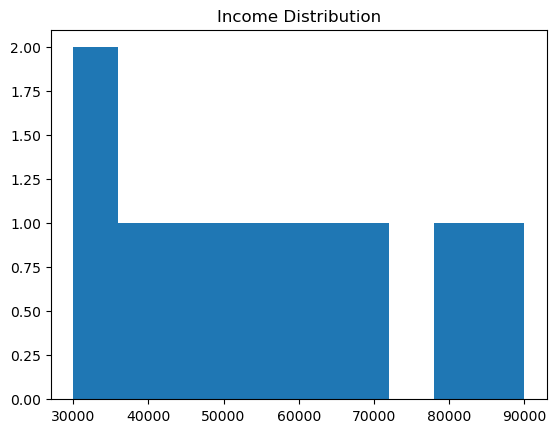

In [11]:
plt.hist(Loan_Data["Income"])
plt.title("Income Distribution")
plt.show()

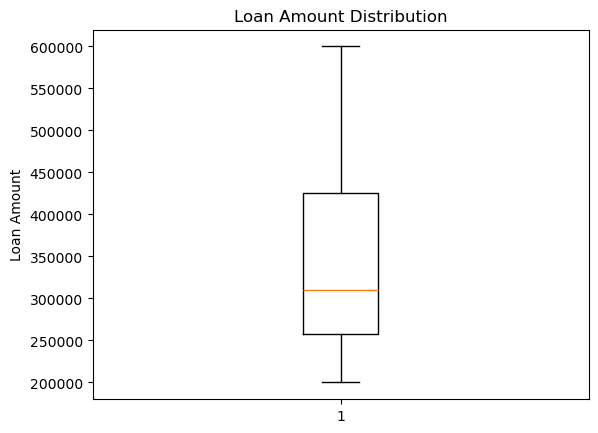

In [19]:
plt.boxplot(Loan_Data["Loan_Amount"])
plt.title("Loan Amount Distribution")
plt.ylabel("Loan Amount")
plt.show()

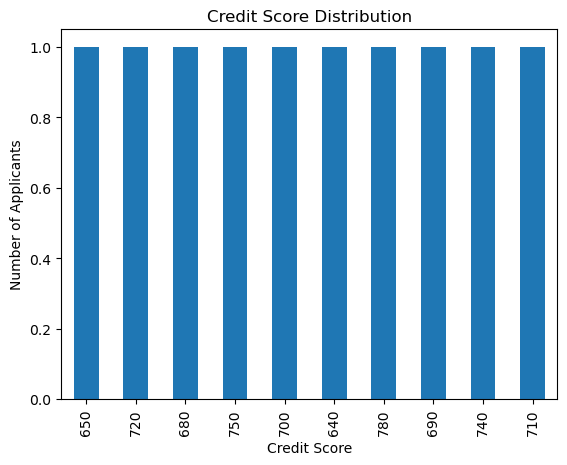

In [20]:
credit_counts = Loan_Data["Credit_Score"].value_counts()

credit_counts.plot(kind="bar")

plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Number of Applicants")
plt.show()

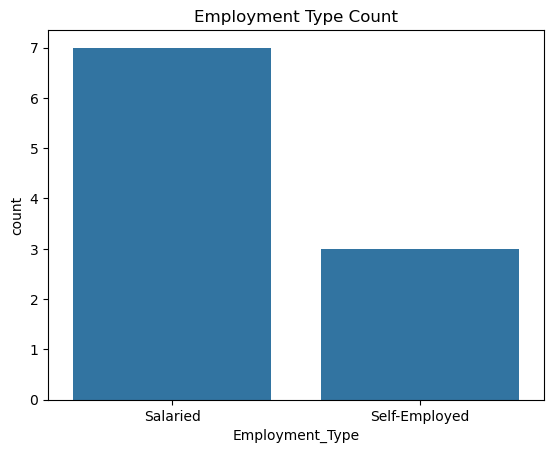

In [14]:
sns.countplot(x="Employment_Type", data=Loan_Data)
plt.title("Employment Type Count")
plt.show()

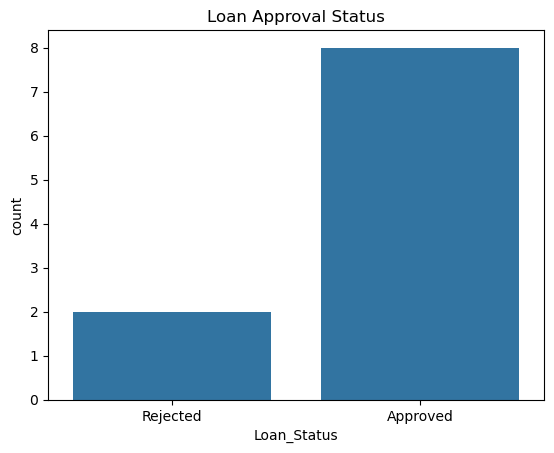

In [15]:
sns.countplot(x="Loan_Status", data=Loan_Data)
plt.title("Loan Approval Status")
plt.show()

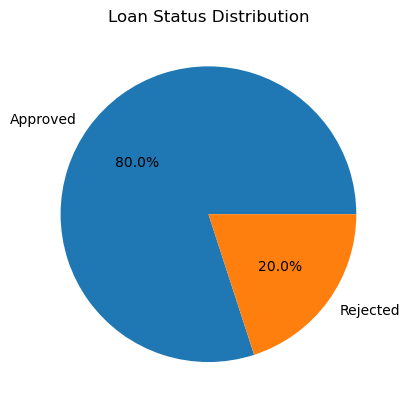

In [18]:
loan_status_counts = Loan_Data["Loan_Status"].value_counts()

plt.pie(loan_status_counts, labels=loan_status_counts.index, autopct='%1.1f%%')
plt.title("Loan Status Distribution")
plt.show()

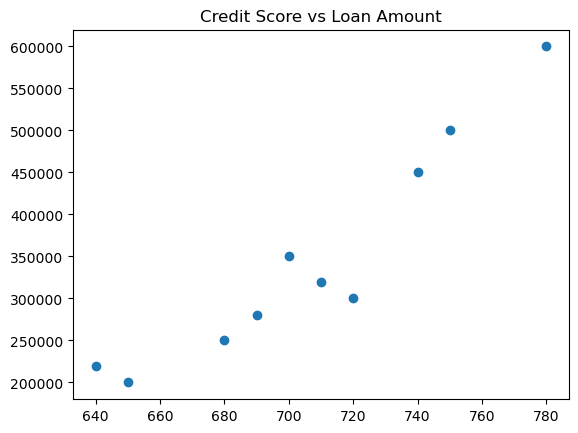

In [17]:
plt.scatter(Loan_Data["Credit_Score"], Loan_Data["Loan_Amount"])
plt.title("Credit Score vs Loan Amount")
plt.show()